In [1]:
# ===== 1) Import library =====
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ===== 2) Load data =====
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
# ===== 3) Model baseline =====
rf = RandomForestClassifier(random_state=42)  # default parameters
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [4]:
# ===== 4) Evaluasi =====
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Random Forest - Baseline ===")
print(f"Recall  : {recall:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== Random Forest - Baseline ===
Recall  : 0.4733
ROC-AUC : 0.7796

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.86      0.84      1033
       Churn       0.55      0.47      0.51       374

    accuracy                           0.76      1407
   macro avg       0.68      0.67      0.67      1407
weighted avg       0.75      0.76      0.75      1407



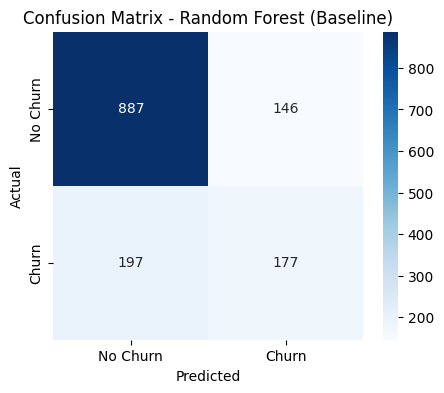

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Baseline)")
plt.show()
